In [1]:
import pandas as pd

pd.set_option('display.float_format', '{:,.2f}'.format)


In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from scipy import stats

In [6]:
from datetime import datetime

In [7]:
import warnings

In [8]:
warnings.filterwarnings('ignore')

In [10]:
df=pd.read_csv( "car_sales.csv",encoding='latin-1'
)
df

,Date,Salesperson,Customer Name,Customer Age,Customer Gender,Car Make,Car Model,Car Year,Quantity,Sale Price,...,Discount,Payment Method,Commission Rate,Commission Earned,Sales Region,Sale Year,Sale Month,Sale Quarter,Day of Week,Season
0,2019-04-02,Mary Simon,Kristin Blackwell,42,Male,Hyundai,Santa Fe,2019,1,"25,949.00",...,0.05,Loan,0.07,"1,816.43",Alaska,"2,019.00",April,2.00,Tuesday,Spring
1,2018-04-13,Nancy Mercado,Diana Black,65,Female,Ford,Explorer,2021,2,"82,236.84",...,0.02,Cash,0.05,"4,111.84",Alabama,"2,023.00",April,2.00,Friday,Spring
2,2021-01-31,Pamela King,Craig Powers,67,Female,Kia,Telluride,2023,2,"60,810.48",...,0.01,Lease,0.06,0.00,South Carolina,"2,024.00",January,1.00,Sunday,Winter
3,2020-09-30,Elizabeth Ashley,Jade Williams,69,Female,BMW,5 Series,2022,2,"154,746.56",...,0.04,Lease,0.06,"9,284.79",Maryland,"2,024.00",September,3.00,Wednesday,Fall
4,2020-07-03,Brian Cline,Nicholas Fernandez,50,Male,Audi,A6,2019,1,"48,629.00",...,0.06,Loan,0.09,"4,376.61",Colorado,"2,019.00",July,3.00,Friday,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107346,2022-10-05,Samantha Cooper,Joe Russell,41,Female,Chevrolet,Silverado,2019,3,"122,334.03",...,0.13,Loan,0.06,"7,340.04",Connecticut,"2,022.00",October,4.00,Wednesday,Fall
107347,2019-05-28,Joshua Morales,Kyle Christian,40,Female,Nissan,Sentra,2022,2,"54,450.44",...,0.05,Lease,0.07,"3,811.53",Delaware,"2,019.00",May,2.00,Tuesday,Spring
107348,2018-04-04,Dr. Diane Mccoy,Matthew Cobb,25,Male,BMW,3 Series,2018,3,"243,849.06",...,0.03,Cash,0.06,"14,630.94",Kansas,"2,024.00",April,2.00,Wednesday,Spring
107349,2021-01-21,Erin Gomez,Brent Jones,43,Male,Honda,Pilot,2023,2,"64,171.92",...,0.02,Loan,0.07,"4,492.03",Maine,"2,021.00",January,1.00,Thursday,Winter


In [11]:
print("Dataset shape:", df.shape)

Dataset shape: (107351, 22)


In [12]:
print(df.head(15))

          Date        Salesperson       Customer Name  Customer Age  \
0   2019-04-02         Mary Simon   Kristin Blackwell            42   
1   2018-04-13      Nancy Mercado         Diana Black            65   
2   2021-01-31        Pamela King        Craig Powers            67   
3   2020-09-30   Elizabeth Ashley       Jade Williams            69   
4   2020-07-03        Brian Cline  Nicholas Fernandez            50   
5   2019-07-26         Alan Ramos        John Nichols            41   
6   2019-02-24     Rebekah Turner     Kenneth Jimenez            25   
7   2024-02-12   Jessica Schaefer      Melissa Newman            23   
8   2018-12-23        Brian Cline       Mark Robinson            24   
9   2024-08-15  Christopher Scott        Susan Flores            56   
10  2022-09-25       David Mullen       Autumn Brewer            26   
11  2018-05-11  Christopher Scott       Chase Collins            33   
12  2018-05-03     Richard Rogers        Judith Baker            64   
13  20

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107351 entries, 0 to 107350
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date               107351 non-null  object 
 1   Salesperson        107351 non-null  object 
 2   Customer Name      107351 non-null  object 
 3   Customer Age       107351 non-null  int64  
 4   Customer Gender    107351 non-null  object 
 5   Car Make           107351 non-null  object 
 6   Car Model          107351 non-null  object 
 7   Car Year           107351 non-null  int64  
 8   Quantity           107351 non-null  int64  
 9   Sale Price         107351 non-null  float64
 10  Cost               107351 non-null  float64
 11  Profit             107351 non-null  float64
 12  Discount           107350 non-null  float64
 13  Payment Method     107350 non-null  object 
 14  Commission Rate    107350 non-null  float64
 15  Commission Earned  107350 non-null  float64
 16  Sa

In [14]:
print("Columns:", df.columns)


Columns: Index(['Date', 'Salesperson', 'Customer Name', 'Customer Age',
       'Customer Gender', 'Car Make', 'Car Model', 'Car Year', 'Quantity',
       'Sale Price', 'Cost', 'Profit', 'Discount', 'Payment Method',
       'Commission Rate', 'Commission Earned', 'Sales Region', 'Sale Year',
       'Sale Month', 'Sale Quarter', 'Day of Week', 'Season'],
      dtype='object')


In [15]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['Customer Age', 'Car Year', 'Quantity', 'Sale Price', 'Cost', 'Profit', 'Discount', 'Commission Rate', 'Commission Earned', 'Sale Year', 'Sale Quarter']
Categorical: ['Date', 'Salesperson', 'Customer Name', 'Customer Gender', 'Car Make', 'Car Model', 'Payment Method', 'Sales Region', 'Sale Month', 'Day of Week', 'Season']


In [16]:
missing = df.isnull().sum()
print("Missing values:\n", missing)
df['Revenue'] = df['Quantity'] * df['Sale Price']


Missing values:
 Date                 0
Salesperson          0
Customer Name        0
Customer Age         0
Customer Gender      0
Car Make             0
Car Model            0
Car Year             0
Quantity             0
Sale Price           0
Cost                 0
Profit               0
Discount             1
Payment Method       1
Commission Rate      1
Commission Earned    1
Sales Region         1
Sale Year            1
Sale Month           1
Sale Quarter         1
Day of Week          1
Season               1
dtype: int64


In [17]:
df['Car Make'] = df['Car Make'].str.strip().str.title()

In [18]:
df['Car Model'] = df['Car Model'].str.strip().str.title()

In [19]:
df['Sale Price'] = pd.to_numeric(df['Sale Price'], errors='coerce')


In [20]:
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

In [21]:
Q1 = df['Sale Price'].quantile(0.25)
Q3 = df['Sale Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df['Sale Price'] < lower_bound) | (df['Sale Price'] > upper_bound)]
print("Number of outliers in price:", len(outliers))

# Optionally remove outliers
df = df[(df['Sale Price'] >= lower_bound) & (df['Sale Price'] <= upper_bound)]


Number of outliers in price: 2973


In [22]:
brand_counts = df['Car Make'].value_counts()
print("Top 10 Brands:\n", brand_counts.head(10))

Top 10 Brands:
 Car Make
Hyundai      10955
Toyota       10831
Ford         10788
Honda        10715
Kia          10692
Nissan       10658
Chevrolet    10611
Audi          9998
Bmw           9989
Mercedes      9141
Name: count, dtype: int64


In [23]:
df['Car Make'] = df['Car Make'].str.upper().str.strip()
df['Payment Method'] = df['Payment Method'].str.title()


Top 10 car brands per year

In [24]:
df_covid = df[df['Sale Year'].isin([2019, 2020, 2021])]

top10 = (
    df_covid
    .groupby(['Sale Year', 'Car Make'])
    .agg({'Quantity':'sum'})
    .reset_index()
)

top10 = (
    top10
    .sort_values(['Sale Year','Quantity'], ascending=False)
    .groupby('Sale Year')
    .head(10)
)
table_top10 = (
    top10
    .pivot(index='Car Make', columns='Sale Year', values='Quantity')
    .fillna(0)
    .astype(int)
    .sort_values(by=2021, ascending=False)
)

table_top10



Sale Year,"2,019.00","2,020.00","2,021.00"
Car Make,,,
HYUNDAI,1044,885,4050
KIA,1097,923,4049
NISSAN,1051,936,3904
CHEVROLET,1015,864,3875
TOYOTA,1073,959,3822
HONDA,1039,958,3763
FORD,1033,921,3718
BMW,1070,887,3655
AUDI,1066,886,3639


In [25]:
table_top10.style \
    .background_gradient(cmap='Blues', axis=1) \
    .set_caption("Top 10 Car Brands Sales (2019–2021) – COVID Impact") \
    .format("{:,}")


Sale Year,2019.000000,2020.000000,2021.000000
Car Make,,,
HYUNDAI,"1,044",885,"4,050"
KIA,"1,097",923,"4,049"
NISSAN,"1,051",936,"3,904"
CHEVROLET,"1,015",864,"3,875"
TOYOTA,"1,073",959,"3,822"
HONDA,"1,039",958,"3,763"
FORD,"1,033",921,"3,718"
BMW,"1,070",887,"3,655"
AUDI,"1,066",886,"3,639"


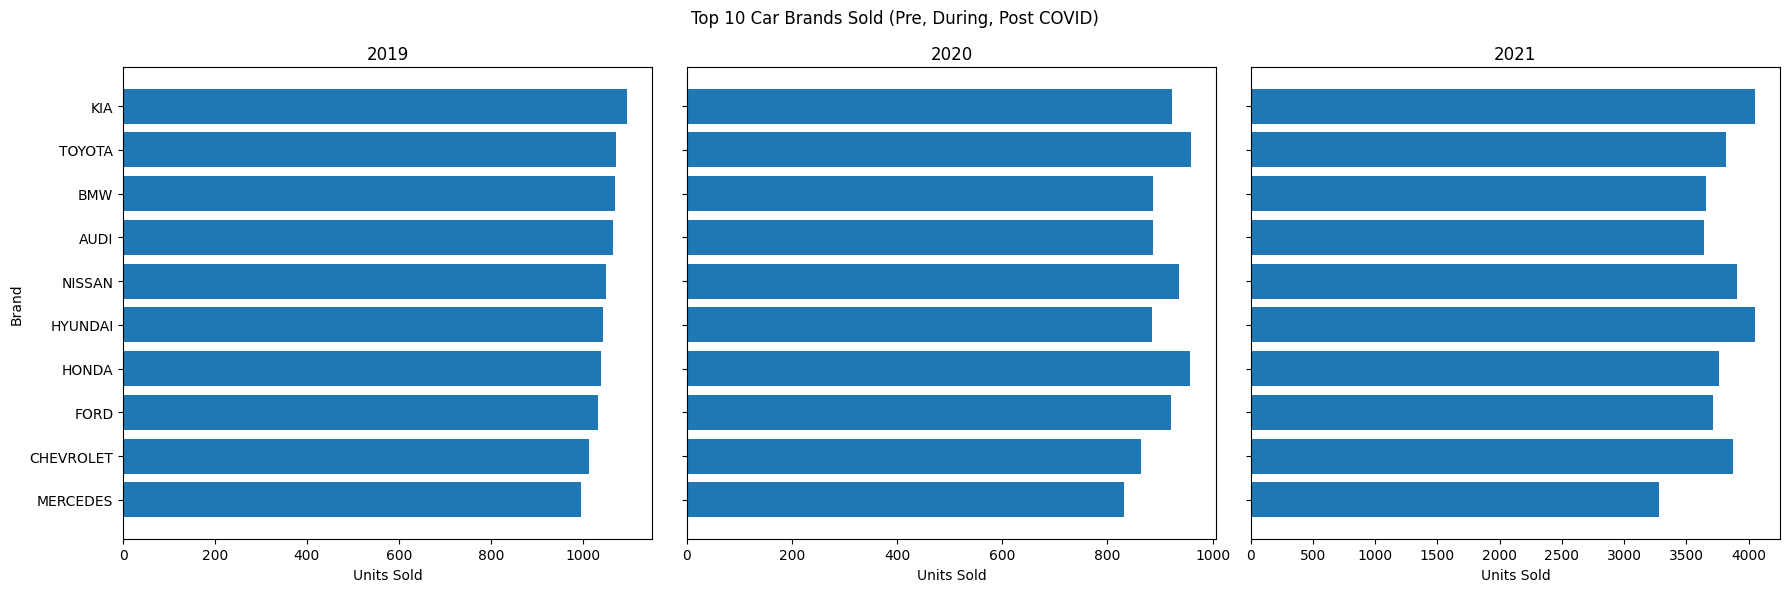

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, year in enumerate([2019, 2020, 2021]):
    data = top10[top10['Sale Year'] == year].sort_values('Quantity')
    axes[i].barh(data['Car Make'], data['Quantity'])
    axes[i].set_title(str(year))
    axes[i].set_xlabel("Units Sold")

axes[0].set_ylabel("Brand")
plt.suptitle("Top 10 Car Brands Sold (Pre, During, Post COVID)")
plt.tight_layout()
plt.show()


SALES EVOLUTION (COVID SHOCK)

In [27]:
monthly_sales = (
    df.groupby(['Sale Year','Sale Month'])
      .agg({'Sale Price':'sum'})
      .reset_index()
)

monthly_sales = monthly_sales[monthly_sales['Sale Year'].isin([2019,2020,2021])]


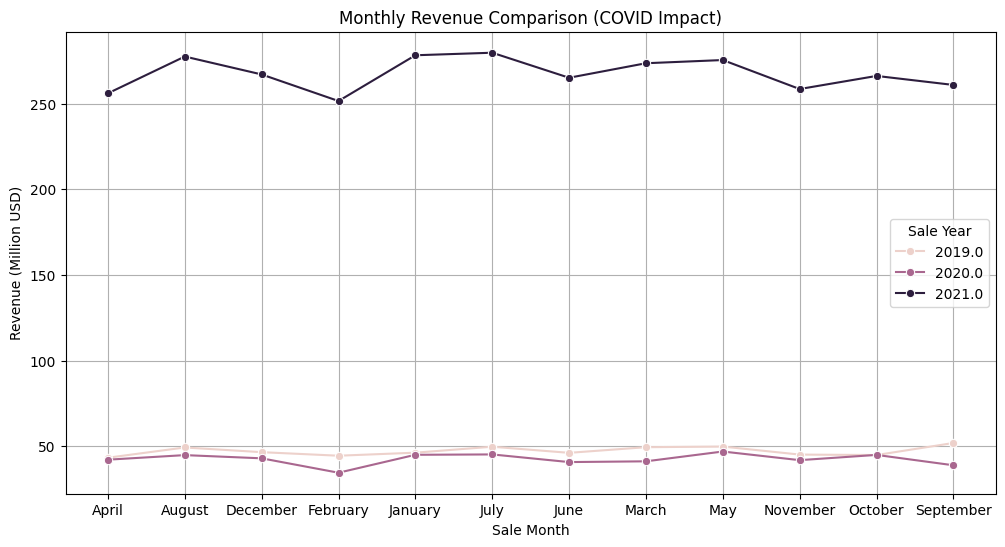

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter COVID years
df_covid = df[df['Sale Year'].isin([2019, 2020, 2021])]

# Monthly revenue per year
monthly_revenue = (
    df_covid
    .groupby(['Sale Year', 'Sale Month'])
    .agg({
        'Revenue': 'sum'
    })
    .reset_index()
)
monthly_revenue['Revenue_M'] = (monthly_revenue['Revenue'] / 1_000_000).round(2)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x='Sale Month',
    y='Revenue_M',
    hue='Sale Year',
    marker='o'
)

plt.ylabel("Revenue (Million USD)")
plt.title("Monthly Revenue Comparison (COVID Impact)")
plt.grid(True)
plt.show()



In [29]:
df_covid.groupby('Sale Year')['Customer Age'].mean()


,Customer Age
Sale Year,
"2,019.00",45.26
"2,020.00",45.26
"2,021.00",44.98


In [30]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print("Number of outliers in Profit:", len(outliers))

# Optionally remove outliers
df = df[(df['Profit'] >= lower_bound) & (df['Profit'] <= upper_bound)]

Number of outliers in Profit: 1610


In [31]:
cols = ['Quantity', 'Sale Price', 'Cost', 'Profit', 'Discount', 'Revenue']

stats = df[cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
stats.rename(columns={'50%': 'median'}, inplace=True)

stats.round(2)


,mean,median,std,min,max
Quantity,2.08,2.00,0.59,1.00,3.00
Sale Price,"78,793.68","71,839.26","34,352.91","9,508.00","184,965.69"
Cost,"62,197.82","57,669.08","26,347.78","8,425.62","197,625.50"
Profit,"16,595.86","15,186.79","12,420.32","-17,013.92","49,448.37"
Discount,0.06,0.06,0.04,0.00,0.15
Revenue,"175,332.01","150,759.08","104,088.78","9,508.00","554,897.07"


Vehicles per brand

In [32]:
brand_distribution = (
    df['Car Make']
    .value_counts()
    .reset_index()
)

brand_distribution.columns = ['Car Make', 'Number of Vehicles']
brand_distribution


,Car Make,Number of Vehicles
0,HYUNDAI,10955
1,TOYOTA,10831
2,FORD,10766
3,HONDA,10715
4,KIA,10692
5,NISSAN,10658
6,CHEVROLET,10605
7,AUDI,9533
8,BMW,9459
9,MERCEDES,8554


 rare brands

In [33]:

df['Car Make'].value_counts().tail()


,count
Car Make,
NISSAN,10658
CHEVROLET,10605
AUDI,9533
BMW,9459
MERCEDES,8554


Most Frequent Car Brand

In [34]:
most_frequent_brand = df['Car Make'].value_counts().idxmax()
most_frequent_count = df['Car Make'].value_counts().max()

most_frequent_brand, most_frequent_count


('HYUNDAI', 10955)

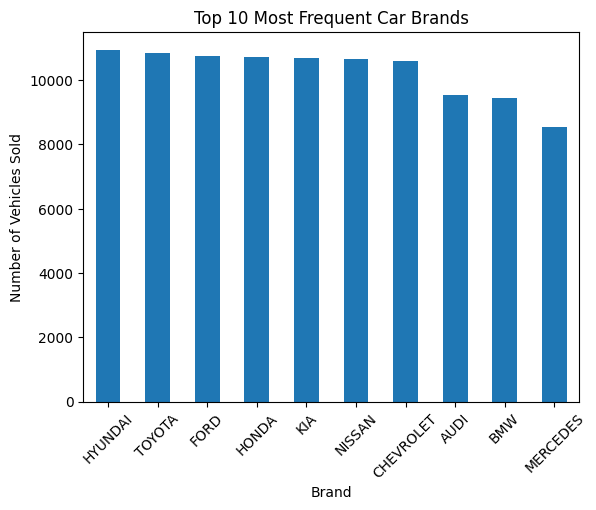

In [35]:
import matplotlib.pyplot as plt

df['Car Make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Frequent Car Brands")
plt.ylabel("Number of Vehicles Sold")
plt.xlabel("Brand")
plt.xticks(rotation=45)
plt.show()


Vehicle Prices (Sale Price)

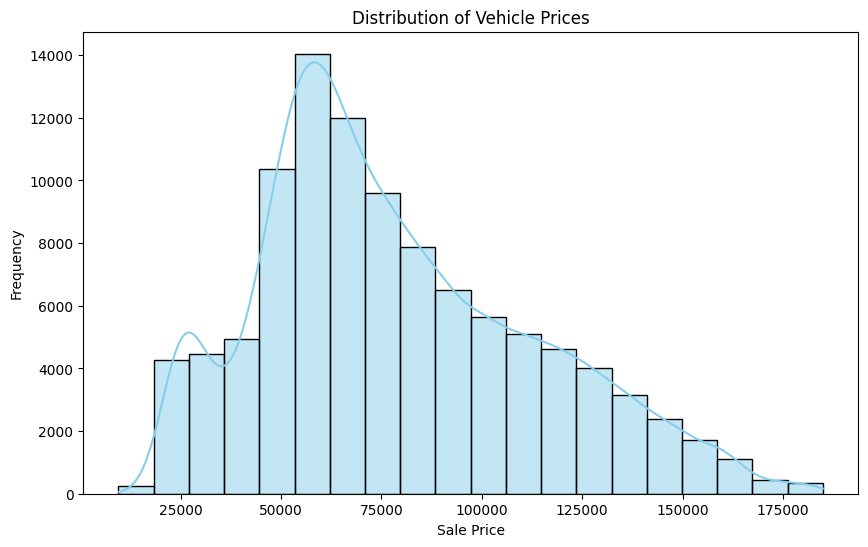

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sale Price'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

In [37]:
price_skew = df['Sale Price'].skew()
print(f"Skewness of Sale Price: {price_skew}")
if price_skew > 0:
    print("The distribution is right-skewed (long tail to the right).")
elif price_skew < 0:
    print("The distribution is left-skewed (long tail to the left).")
else:
    print("The distribution is approximately symmetric.")

Skewness of Sale Price: 0.5849990043740331
The distribution is right-skewed (long tail to the right).


Relationship between Car Year and Sale Price

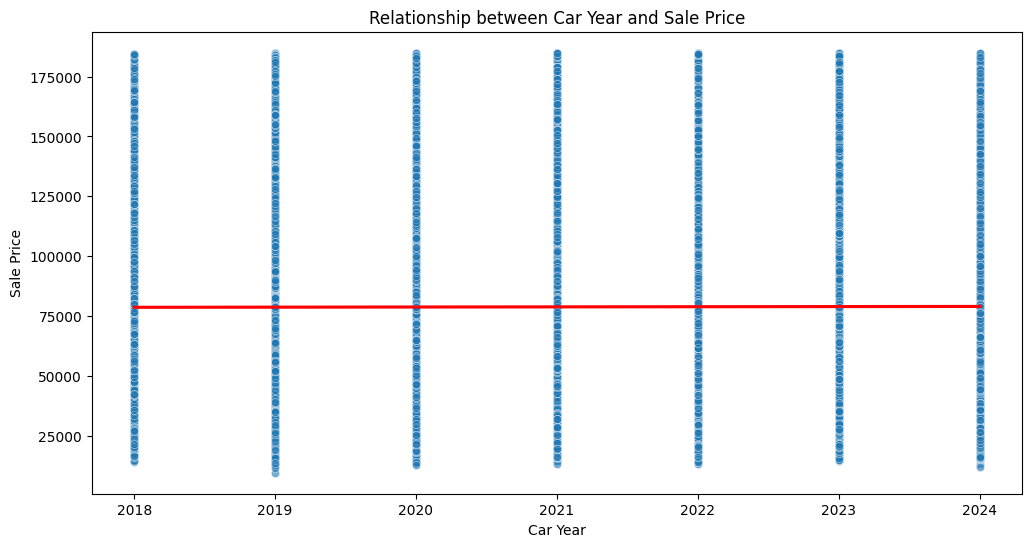

In [38]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Car Year', y='Sale Price', data=df, alpha=0.6)
sns.regplot(x='Car Year', y='Sale Price', data=df, scatter=False, color='red')  # trend line
plt.title('Relationship between Car Year and Sale Price')
plt.xlabel('Car Year')
plt.ylabel('Sale Price')
plt.show()

Observation: Are newer cars more expensive?

In [39]:
cor_price_year = df['Car Year'].corr(df['Sale Price'])
print(f"Correlation between Car Year and Sale Price: {cor_price_year:.2f}")
if cor_price_year > 0:
    print("Positive correlation: Newer cars tend to be more expensive.")
elif cor_price_year < 0:
    print("Negative correlation: Older cars tend to be more expensive.")
else:
    print("No clear correlation between car year and price.")

Correlation between Car Year and Sale Price: 0.00
Positive correlation: Newer cars tend to be more expensive.


Correlation matrix between numerical variables

In [40]:
numerical_cols = ['Customer Age', 'Quantity', 'Sale Price', 'Discount', 'Commission Rate', 'Commission Earned']
corr_matrix = df[numerical_cols].corr()



In [41]:
print("\nInterpretation:")
for col in numerical_cols:
    high_corrs = corr_matrix[col][(corr_matrix[col] > 0.5) & (corr_matrix[col] < 1)]
    if not high_corrs.empty:
        print(f"{col} has notable positive correlation with: {list(high_corrs.index)}")
    low_corrs = corr_matrix[col][(corr_matrix[col] < -0.5)]
    if not low_corrs.empty:
        print(f"{col} has notable negative correlation with: {list(low_corrs.index)}")


Interpretation:
Quantity has notable positive correlation with: ['Sale Price']
Sale Price has notable positive correlation with: ['Quantity', 'Commission Earned']
Commission Earned has notable positive correlation with: ['Sale Price']


In [42]:
df['Date'] = pd.to_datetime(df['Date'])

# 1️⃣ Regroupement par mois
monthly_data = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Quantity': 'sum',
    'Sale Price': 'sum'  # On suppose que Sale Price * Quantity = Revenue
})

monthly_data.rename(columns={'Sale Price': 'Total Revenue'}, inplace=True)
monthly_data.index = monthly_data.index.to_timestamp()

In [43]:
weekly_data = df.groupby(df['Date'].dt.to_period('W')).agg({
    'Quantity': 'sum',
    'Sale Price': 'sum'
})

weekly_data.rename(columns={'Sale Price': 'Total Revenue'}, inplace=True)
weekly_data.index = weekly_data.index.to_timestamp()

détecter les pics et baisses

Calculer le z-score pour la quantité

In [44]:
from scipy.stats import zscore

monthly_data['Quantity_z'] = zscore(monthly_data['Quantity'])

# Définir un seuil pour détecter les anomalies
threshold = 2  # z-score > 2 ou < -2
peaks = monthly_data[monthly_data['Quantity_z'] > threshold]
drops = monthly_data[monthly_data['Quantity_z'] < -threshold]

print("Périodes avec pic exceptionnel de ventes :")
print(peaks[['Quantity', 'Quantity_z']])
print("\nPériodes avec baisse significative de ventes :")
print(drops[['Quantity', 'Quantity_z']])

Périodes avec pic exceptionnel de ventes :
            Quantity  Quantity_z
Date                            
2019-03-01      2787        2.56
2019-07-01      2771        2.39

Périodes avec baisse significative de ventes :
            Quantity  Quantity_z
Date                            
2021-02-01      2358       -2.08
2022-02-01      2332       -2.36
2023-02-01      2356       -2.10
2024-02-01      2309       -2.61


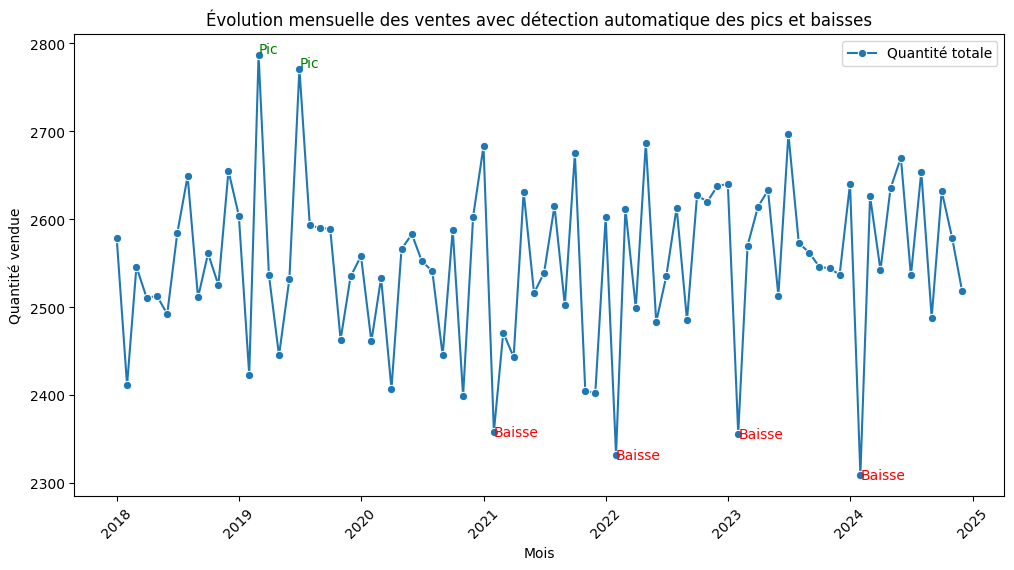

In [45]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_data, x=monthly_data.index, y='Quantity', marker='o', label='Quantité totale')
for idx in peaks.index:
    plt.text(idx, monthly_data.loc[idx, 'Quantity']+2, 'Pic', color='green', fontsize=10)
for idx in drops.index:
    plt.text(idx, monthly_data.loc[idx, 'Quantity']-5, 'Baisse', color='red', fontsize=10)
plt.title('Évolution mensuelle des ventes avec détection automatique des pics et baisses')
plt.xlabel('Mois')
plt.ylabel('Quantité vendue')
plt.xticks(rotation=45)
plt.show()

In [46]:
from scipy.stats import skew
df['Revenue'] = df['Quantity'] * df['Sale Price']
cols = ['Quantity', 'Sale Price', 'Revenue']
for col in cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = skew(df[col])

    print(f"--- {col} ---")
    print(f"Moyenne: {mean_val:.2f}")
    print(f"Médiane: {median_val:.2f}")
    print(f"Asymétrie (skewness): {skew_val:.2f}")

    if skew_val > 0:
        print("Distribution asymétrique à droite (longue queue vers les valeurs élevées)\n")
    elif skew_val < 0:
        print("Distribution asymétrique à gauche (longue queue vers les valeurs faibles)\n")
    else:
        print("Distribution approximativement symétrique\n")

--- Quantity ---
Moyenne: 2.08
Médiane: 2.00
Asymétrie (skewness): -0.02
Distribution asymétrique à gauche (longue queue vers les valeurs faibles)

--- Sale Price ---
Moyenne: 78793.68
Médiane: 71839.26
Asymétrie (skewness): 0.58
Distribution asymétrique à droite (longue queue vers les valeurs élevées)

--- Revenue ---
Moyenne: 175332.01
Médiane: 150759.08
Asymétrie (skewness): 0.86
Distribution asymétrique à droite (longue queue vers les valeurs élevées)



In [47]:
numerical_cols = ['Quantity', 'Sale Price', 'Revenue', 'Discount', 'Commission Rate', 'Commission Earned', 'Customer Age']
std_values = df[numerical_cols].std()
print("Écarts-types des variables numériques :\n")
print(std_values)

# Interprétation
print("\nInterprétation :")
for col in numerical_cols:
    print(f"- {col} : écart-type = {std_values[col]:.2f}", end=" → ")
    if std_values[col] / df[col].mean() > 1:
        print("très dispersé par rapport à la moyenne")
    elif std_values[col] / df[col].mean() > 0.5:
        print("dispersion modérée")
    else:
        print("faible dispersion")

Écarts-types des variables numériques :

Quantity                  0.59
Sale Price           34,352.91
Revenue             104,088.78
Discount                  0.04
Commission Rate           0.02
Commission Earned     3,115.68
Customer Age             14.75
dtype: float64

Interprétation :
- Quantity : écart-type = 0.59 → faible dispersion
- Sale Price : écart-type = 34352.91 → faible dispersion
- Revenue : écart-type = 104088.78 → dispersion modérée
- Discount : écart-type = 0.04 → dispersion modérée
- Commission Rate : écart-type = 0.02 → faible dispersion
- Commission Earned : écart-type = 3115.68 → dispersion modérée
- Customer Age : écart-type = 14.75 → faible dispersion


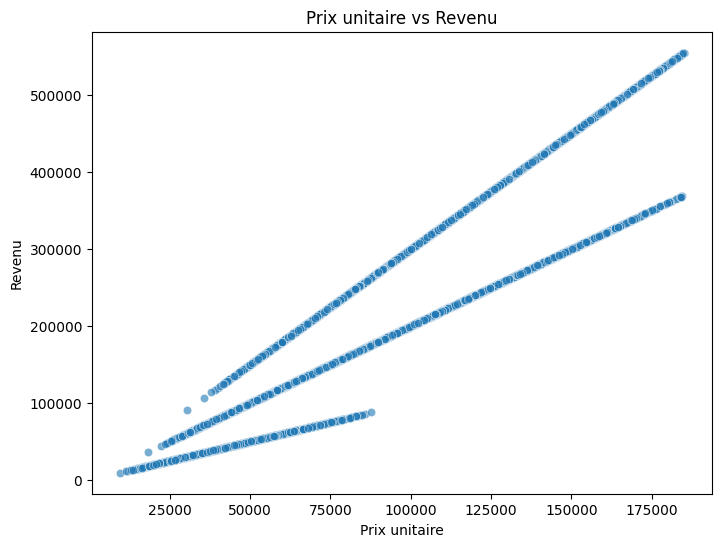

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sale Price', y='Revenue', data=df, alpha=0.6)
plt.title('Prix unitaire vs Revenu')
plt.xlabel('Prix unitaire')
plt.ylabel('Revenu')
plt.show()

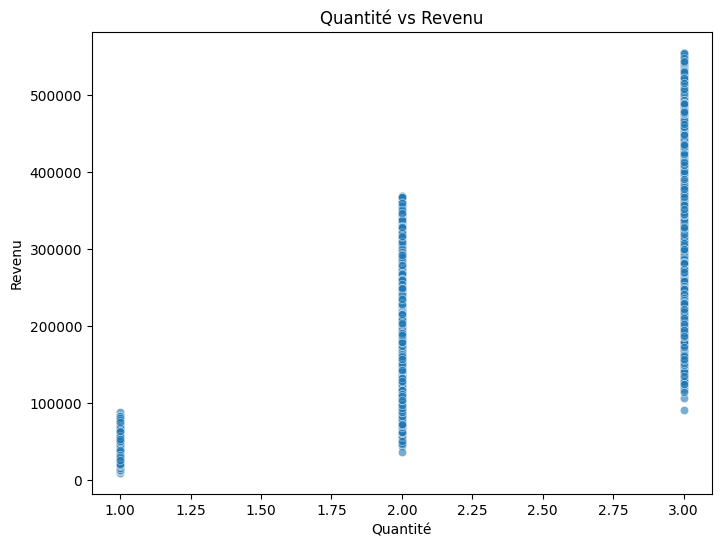

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Quantity', y='Revenue', data=df, alpha=0.6)
plt.title('Quantité vs Revenu')
plt.xlabel('Quantité')
plt.ylabel('Revenu')
plt.show()


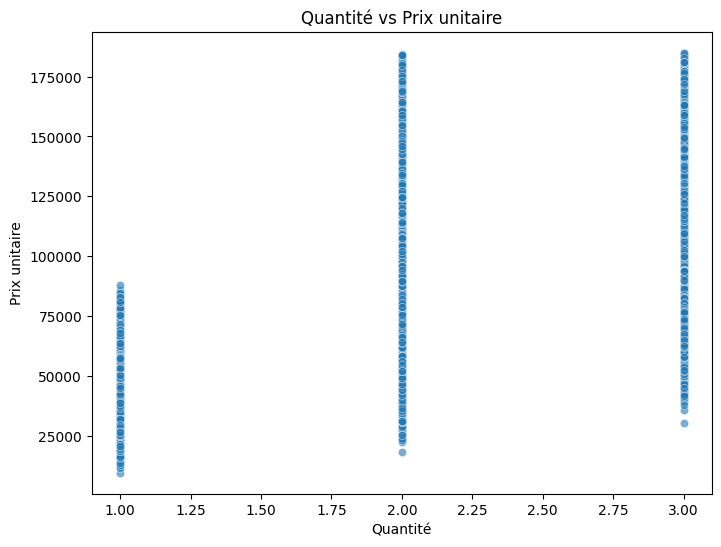

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Quantity', y='Sale Price', data=df, alpha=0.6)
plt.title('Quantité vs Prix unitaire')
plt.xlabel('Quantité')
plt.ylabel('Prix unitaire')
plt.show()



Prix unitaire vs Revenu
plus le prix d’une voiture est élevé, plus le revenu de la vente augmente.
Quantité vs Revenu
plus de voitures vendues → plus de revenu.

Certaines ventes avec quantité faible mais prix élevé peuvent générer un revenu similaire à des ventes avec quantité élevée mais prix bas.

égression linéaire simple (Sale Price → Revenue)

In [51]:
from sklearn.linear_model import LinearRegression


In [52]:
df['Revenue'] = df['Quantity'] * df['Sale Price']


In [53]:
X_simple = df[['Sale Price']]  # variable indépendante
y = df['Revenue']              # variable dépendante


In [54]:
# Créer et entraîner le modèle
model_simple = LinearRegression()
model_simple.fit(X_simple, y)



LinearRegression()

In [55]:
# Coefficients
print("Régression linéaire simple :")
print(f"Intercept: {model_simple.intercept_:.2f}")
print(f"Coefficient pour Sale Price: {model_simple.coef_[0]:.2f}")
# Prédictions
y_pred_simple = model_simple.predict(X_simple)


Régression linéaire simple :
Intercept: -44010.62
Coefficient pour Sale Price: 2.78


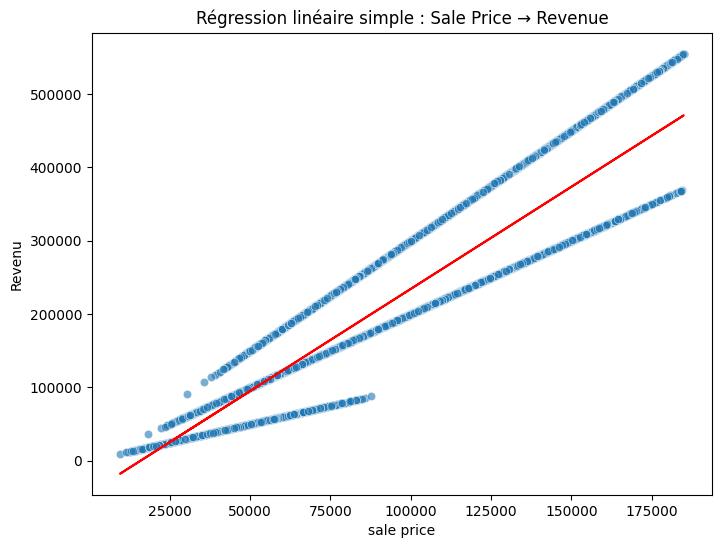

In [56]:
# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sale Price', y='Revenue', data=df, alpha=0.6)
plt.plot(df['Sale Price'], y_pred_simple, color='red')  # ligne de régression
plt.title('Régression linéaire simple : Sale Price → Revenue')
plt.xlabel('sale price')
plt.ylabel('Revenu')
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
# Variables indépendantes
X_multi = df[['Sale Price', 'Quantity', 'Discount', 'Commission Rate']]
y = df['Revenue']

In [62]:
combined_df = pd.concat([X_multi, y], axis=1)
combined_df.dropna(inplace=True)

X_multi_cleaned = combined_df[['Sale Price', 'Quantity', 'Discount', 'Commission Rate']]
y_cleaned = combined_df['Revenue']

# Séparer en train et test
X_train, X_test, y_train, y_test = train_test_split(X_multi_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Créer et entraîner le modèle
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Prédictions
y_pred_multi = model_multi.predict(X_test)

In [63]:

# Coefficients
coeff_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=['Coefficient'])
print("Régression linéaire multiple :")
print(coeff_df)
print(f"Intercept: {model_multi.intercept_:.2f}")

Régression linéaire multiple :
                 Coefficient
Sale Price              2.12
Quantity           70,749.94
Discount          -33,296.44
Commission Rate     1,672.28
Intercept: -137411.71


In [64]:

# Évaluer le modèle
mse = mean_squared_error(y_test, y_pred_multi)
r2 = r2_score(y_test, y_pred_multi)
print(f"\nMean Squared Error: {mse:.2f}")
print(f"R² score: {r2:.2f}")


Mean Squared Error: 461347826.67
R² score: 0.96


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [66]:

# Créer un tableau d’indicateurs par région
region_summary = df.groupby('Sales Region').agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'Sale Price': 'mean'
}).reset_index()
region_summary.rename(columns={
    'Revenue': 'Average Revenue',
    'Quantity': 'Average Quantity',
    'Sale Price': 'Average Sale Price'
}, inplace=True)

print(region_summary)

      Sales Region  Average Revenue  Average Quantity  Average Sale Price
0          Alabama       173,470.78              2.07           78,599.74
1           Alaska       176,282.44              2.07           79,712.73
2          Arizona       175,865.79              2.08           79,087.18
3         Arkansas       175,446.25              2.09           78,627.60
4       California       175,005.69              2.08           78,608.82
5         Colorado       177,271.14              2.10           79,141.17
6      Connecticut       175,282.18              2.08           79,078.57
7         Delaware       175,771.49              2.08           79,000.12
8          Florida       176,629.41              2.09           79,295.39
9          Georgia       172,395.38              2.07           77,806.64
10          Hawaii       172,449.33              2.06           78,234.87
11           Idaho       170,531.79              2.06           77,545.02
12        Illinois       175,072.18   

Standardiser les données

In [67]:
features = ['Average Revenue', 'Average Quantity', 'Average Sale Price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(region_summary[features])


Appliquer K-means

In [68]:
# Choisir le nombre de clusters (par exemple 3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
region_summary['Cluster'] = kmeans.fit_predict(X_scaled)

print(region_summary)


      Sales Region  Average Revenue  Average Quantity  Average Sale Price  \
0          Alabama       173,470.78              2.07           78,599.74   
1           Alaska       176,282.44              2.07           79,712.73   
2          Arizona       175,865.79              2.08           79,087.18   
3         Arkansas       175,446.25              2.09           78,627.60   
4       California       175,005.69              2.08           78,608.82   
5         Colorado       177,271.14              2.10           79,141.17   
6      Connecticut       175,282.18              2.08           79,078.57   
7         Delaware       175,771.49              2.08           79,000.12   
8          Florida       176,629.41              2.09           79,295.39   
9          Georgia       172,395.38              2.07           77,806.64   
10          Hawaii       172,449.33              2.06           78,234.87   
11           Idaho       170,531.79              2.06           77,545.02   

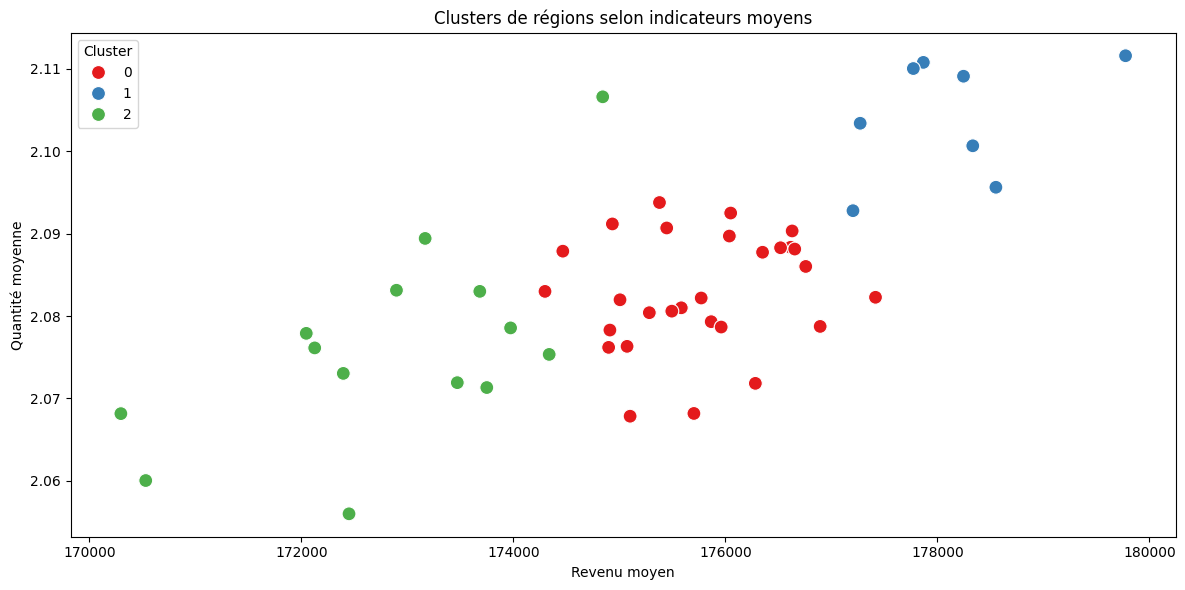

In [69]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Average Revenue', y='Average Quantity', hue='Cluster',
                data=region_summary, palette='Set1', s=100)

region_summary['Region Short'] = region_summary['Sales Region'].str[:10]  # garder les 10 premiers caractères


plt.title('Clusters de régions selon indicateurs moyens')
plt.xlabel('Revenu moyen')
plt.ylabel('Quantité moyenne')
plt.tight_layout()
plt.show()


Interprétation des clusters :

Cluster 0 : régions avec revenu et quantité faibles → moins performantes ou marché petit.

Cluster 1 : régions avec prix élevé mais quantité modérée → produits premium, faible volume.

Cluster 2 : régions avec quantité et revenu élevés → marché fort, produits populaires.

 les régions les plus stables VS
 les régions les plus irrégulières.

In [70]:

# Regrouper par région et calculer moyenne et écart-type du revenu
region_stats = df.groupby('Sales Region').agg({
    'Revenue': ['mean', 'std'],
    'Quantity': ['mean', 'std']
})

# Renommer les colonnes
region_stats.columns = ['Revenue_mean', 'Revenue_std', 'Quantity_mean', 'Quantity_std']
region_stats = region_stats.reset_index()

print(region_stats)

      Sales Region  Revenue_mean  Revenue_std  Quantity_mean  Quantity_std
0          Alabama    173,470.78   101,352.85           2.07          0.57
1           Alaska    176,282.44   105,722.07           2.07          0.58
2          Arizona    175,865.79   105,255.37           2.08          0.59
3         Arkansas    175,446.25   104,483.46           2.09          0.60
4       California    175,005.69   105,280.57           2.08          0.60
5         Colorado    177,271.14   103,204.59           2.10          0.60
6      Connecticut    175,282.18   103,300.26           2.08          0.58
7         Delaware    175,771.49   104,489.50           2.08          0.60
8          Florida    176,629.41   103,363.41           2.09          0.59
9          Georgia    172,395.38   102,919.31           2.07          0.60
10          Hawaii    172,449.33   104,373.58           2.06          0.61
11           Idaho    170,531.79   101,106.83           2.06          0.58
12        Illinois    175

Régions stables → faible écart-type (std)

Régions irrégulières → fort écart-type

In [71]:
# Régions les plus stables (selon Revenue_std)
stable_regions = region_stats.sort_values(by='Revenue_std').head(5)
print("Régions les plus stables :")
print(stable_regions[['Sales Region', 'Revenue_std']])

# Régions les plus irrégulières (selon Revenue_std)
irregular_regions = region_stats.sort_values(by='Revenue_std', ascending=False).head(5)
print("\nRégions les plus irrégulières :")
print(irregular_regions[['Sales Region', 'Revenue_std']])


Régions les plus stables :
   Sales Region  Revenue_std
18        Maine    98,974.97
41    Tennessee   100,280.79
14         Iowa   100,933.90
11        Idaho   101,106.83
17    Louisiana   101,137.10

Régions les plus irrégulières :
     Sales Region  Revenue_std
42          Texas   106,998.06
16       Kentucky   106,732.20
35       Oklahoma   106,261.11
47  West Virginia   106,231.80
40   South Dakota   106,223.65


Produits "phares" → ceux qui génèrent le plus de revenu moyen, ont des ventes régulières et/ou un prix attractif.

Produits à améliorer → ceux qui ont faible revenu moyen, faible quantité vendue ou forte irrégularité dans les ventes.


Car Make (marque)

In [72]:
# Regrouper par produit (marque)
product_stats = df.groupby('Car Make').agg({
    'Revenue': ['mean', 'std'],   # revenu moyen et dispersion
    'Quantity': ['mean', 'std'],  # quantité moyenne et dispersion
    'Sale Price': 'mean'          # prix moyen
})

# Renommer les colonnes
product_stats.columns = ['Revenue_mean', 'Revenue_std', 'Quantity_mean', 'Quantity_std', 'Price_mean']
product_stats = product_stats.reset_index()

print(product_stats)

    Car Make  Revenue_mean  Revenue_std  Quantity_mean  Quantity_std  \
0       AUDI    235,516.52   118,211.55           2.02          0.56   
1        BMW    238,384.53   115,065.05           2.00          0.54   
2  CHEVROLET    178,996.36    99,252.50           2.12          0.60   
3       FORD    196,014.27   110,290.40           2.12          0.61   
4      HONDA    149,420.96    83,309.10           2.11          0.60   
5    HYUNDAI    129,414.19    72,369.20           2.12          0.61   
6        KIA    124,555.77    69,410.84           2.13          0.61   
7   MERCEDES    244,245.05   110,071.59           1.94          0.51   
8     NISSAN    146,868.73    80,768.72           2.13          0.61   
9     TOYOTA    138,933.44    77,390.37           2.11          0.61   

   Price_mean  
0  108,983.02  
1  112,086.76  
2   78,057.17  
3   85,407.03  
4   65,465.27  
5   56,271.54  
6   54,037.69  
7  118,966.58  
8   63,736.37  
9   60,787.41  


Produits phares → fort revenu moyen et quantité moyenne élevée

Produits à améliorer → faible revenu moyen et quantité faible

In [73]:
# Produits phares (top 5 selon Revenue_mean)
top_products = product_stats.sort_values(by='Revenue_mean', ascending=False).head(5)
print("Produits phares :")
print(top_products[['Car Make', 'Revenue_mean', 'Quantity_mean', 'Price_mean']])

# Produits à améliorer (bottom 5 selon Revenue_mean)
bottom_products = product_stats.sort_values(by='Revenue_mean').head(5)
print("\nProduits à améliorer :")
print(bottom_products[['Car Make', 'Revenue_mean', 'Quantity_mean', 'Price_mean']])


Produits phares :
    Car Make  Revenue_mean  Quantity_mean  Price_mean
7   MERCEDES    244,245.05           1.94  118,966.58
1        BMW    238,384.53           2.00  112,086.76
0       AUDI    235,516.52           2.02  108,983.02
3       FORD    196,014.27           2.12   85,407.03
2  CHEVROLET    178,996.36           2.12   78,057.17

Produits à améliorer :
  Car Make  Revenue_mean  Quantity_mean  Price_mean
6      KIA    124,555.77           2.13   54,037.69
5  HYUNDAI    129,414.19           2.12   56,271.54
9   TOYOTA    138,933.44           2.11   60,787.41
8   NISSAN    146,868.73           2.13   63,736.37
4    HONDA    149,420.96           2.11   65,465.27


tendances de consommation par âge

In [74]:
# Créer des tranches d'âge
bins = [18, 25, 35, 45, 55, 65, 100]  # adapter selon les âges de tes clients
labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df['Age Group'] = pd.cut(df['Customer Age'], bins=bins, labels=labels, right=False)

print(df[['Customer Age', 'Age Group']].head())

   Customer Age Age Group
0            42     35-44
1            65       65+
2            67       65+
3            69       65+
4            50     45-54


Analyser les voitures les plus achetées par tranche d’âge

In [75]:
# Regrouper par tranche d'âge et Car Make
age_car_stats = df.groupby(['Age Group', 'Car Make']).agg({
    'Quantity': 'sum',   # combien de voitures achetées
    'Revenue': 'sum'     # revenu généré
}).reset_index()

# Trouver la voiture la plus achetée par tranche d'âge
top_cars_by_age = age_car_stats.loc[age_car_stats.groupby('Age Group')['Quantity'].idxmax()]

print("Voitures les plus achetées par tranche d'âge :")
print(top_cars_by_age[['Age Group', 'Car Make', 'Quantity', 'Revenue']])


Voitures les plus achetées par tranche d'âge :
   Age Group   Car Make  Quantity        Revenue
9      18-24     TOYOTA      2363 155,092,887.41
15     25-34    HYUNDAI      4790 293,194,502.95
22     35-44  CHEVROLET      4507 382,046,242.33
33     45-54       FORD      4623 425,398,698.79
43     55-64       FORD      4563 425,431,373.06
54       65+      HONDA      2832 201,936,779.45


Interprétation possible :

Les jeunes adultes (18-24, 25-34) peuvent préférer des voitures moins chères ou sportives.

Les clients plus âgés peuvent acheter des voitures familiales ou premium.

Cette analyse permet de cibler les promotions et stocks selon l’âge des clients.

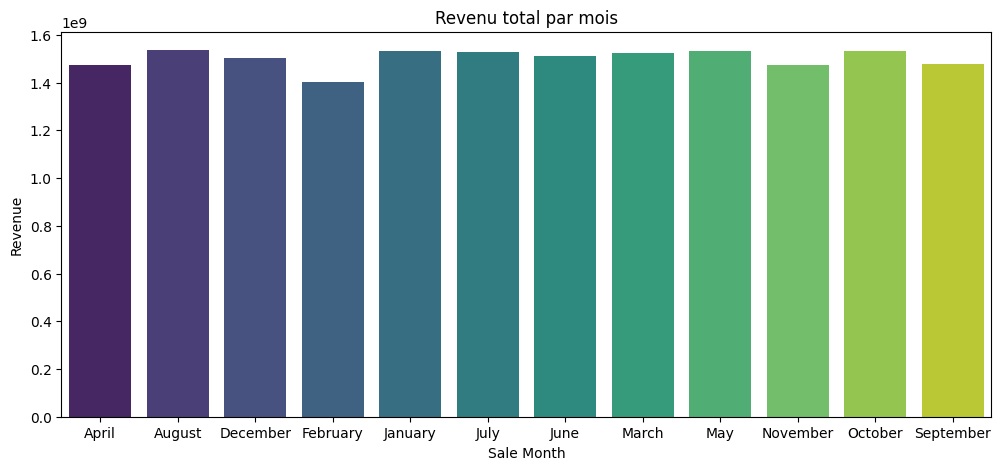

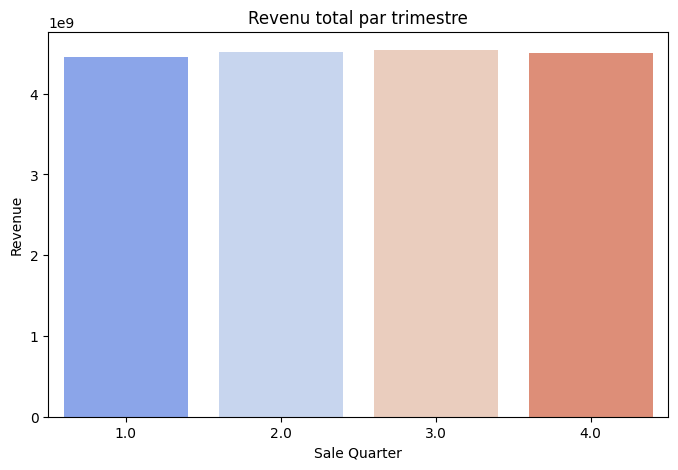

In [76]:
# 1️⃣ Saisonnalité des ventes (par mois et trimestre)
monthly_sales = df.groupby('Sale Month').agg({'Revenue':'sum', 'Quantity':'sum'}).reset_index()
quarterly_sales = df.groupby('Sale Quarter').agg({'Revenue':'sum', 'Quantity':'sum'}).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(x='Sale Month', y='Revenue', data=monthly_sales, palette='viridis')
plt.title("Revenu total par mois")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Sale Quarter', y='Revenue', data=quarterly_sales, palette='coolwarm')
plt.title("Revenu total par trimestre")
plt.show()

In [77]:

print("=== Revenu et quantité par mois ===")
# Exemple pour le revenu
monthly_sales['Revenue_Million'] = (monthly_sales['Revenue'] / 1_000_000).round(2)
print(monthly_sales[['Sale Month', 'Revenue_Million', 'Quantity']])


print("\n=== Revenu et quantité par trimestre ===")
quarterly_sales['Revenue_Million'] = (quarterly_sales['Revenue'] / 1_000_000).round(2)
print(quarterly_sales[['Sale Quarter', 'Revenue_Million', 'Quantity']])


=== Revenu et quantité par mois ===
   Sale Month  Revenue_Million  Quantity
0       April         1,473.02     17551
1      August         1,536.43     18238
2    December         1,501.43     17888
3    February         1,401.63     16650
4     January         1,530.87     18306
5        July         1,527.82     18212
6        June         1,511.49     17789
7       March         1,524.35     18145
8         May         1,531.34     18110
9    November         1,472.01     17535
10    October         1,531.98     18218
11  September         1,476.03     17583

=== Revenu et quantité par trimestre ===
   Sale Quarter  Revenue_Million  Quantity
0          1.00         4,456.85     53101
1          2.00         4,515.85     53450
2          3.00         4,540.29     54033
3          4.00         4,505.42     53641


In [78]:
# Assurer que Revenue est lisible
monthly_sales['Revenue_Million'] = (monthly_sales['Revenue'] / 1_000_000).round(2)

# Top 1 mois
top1_month = monthly_sales.sort_values(by='Revenue', ascending=False).head(1)
print("=== Top 1 mois par revenu ===")
print(top1_month[['Sale Month', 'Revenue_Million', 'Quantity']])

# Top 3 mois
top3_month = monthly_sales.sort_values(by='Revenue', ascending=False).head(3)
print("\n=== Top 3 mois par revenu ===")
print(top3_month[['Sale Month', 'Revenue_Million', 'Quantity']])


=== Top 1 mois par revenu ===
  Sale Month  Revenue_Million  Quantity
1     August         1,536.43     18238

=== Top 3 mois par revenu ===
   Sale Month  Revenue_Million  Quantity
1      August         1,536.43     18238
10    October         1,531.98     18218
8         May         1,531.34     18110


In [79]:
# Assurer que Revenue est lisible
quarterly_sales['Revenue_Million'] = (quarterly_sales['Revenue'] / 1_000_000).round(2)

# Top 1 trimestre
top1_quarter = quarterly_sales.sort_values(by='Revenue', ascending=False).head(1)
print("\n=== Top 1 trimestre par revenu ===")
print(top1_quarter[['Sale Quarter', 'Revenue_Million', 'Quantity']])

# Top 3 trimestres
top3_quarter = quarterly_sales.sort_values(by='Revenue', ascending=False).head(3)
print("\n=== Top 3 trimestres par revenu ===")
print(top3_quarter[['Sale Quarter', 'Revenue_Million', 'Quantity']])



=== Top 1 trimestre par revenu ===
   Sale Quarter  Revenue_Million  Quantity
2          3.00         4,540.29     54033

=== Top 3 trimestres par revenu ===
   Sale Quarter  Revenue_Million  Quantity
2          3.00         4,540.29     54033
1          2.00         4,515.85     53450
3          4.00         4,505.42     53641


In [80]:
dow_sales = df.groupby('Day of Week').agg({'Revenue':'sum', 'Quantity':'sum'}).reset_index()
print("\n=== Revenu et quantité par jour de la semaine ===")
print(dow_sales)


=== Revenu et quantité par jour de la semaine ===
  Day of Week          Revenue  Quantity
0      Friday 2,613,586,940.17     30926
1      Monday 2,569,080,759.66     30559
2    Saturday 2,580,222,822.09     30769
3      Sunday 2,625,416,917.27     31026
4    Thursday 2,560,758,570.90     30419
5     Tuesday 2,567,196,709.69     30544
6   Wednesday 2,502,152,718.64     29982


In [81]:
client_value = df.groupby('Customer Name').agg({'Revenue':'sum', 'Quantity':'sum'}).reset_index()
top_clients = client_value.sort_values(by='Revenue', ascending=False).head(10)
print("\n=== Top 10 clients VIP ===")
print(top_clients)


=== Top 10 clients VIP ===
           Customer Name      Revenue  Quantity
49598      Michael Smith 9,557,985.84       106
14178  Christopher Smith 7,503,610.82        79
49694   Michael Williams 6,702,276.95        81
18083        David Smith 6,344,854.08        81
33896         John Smith 5,997,184.21        70
31270     Jennifer Smith 5,936,949.43        68
49306      Michael Jones 5,704,191.06        62
28684        James Smith 5,436,951.46        67
47362    Matthew Johnson 5,382,497.90        58
28449      James Johnson 5,364,621.10        66


Analyse du prix et promotions : effet du discount

In [82]:
discount_effect = df.groupby('Discount').agg({'Revenue':'sum', 'Quantity':'sum'}).reset_index()
print("\n=== Effet du discount sur le revenu et la quantité ===")
print(discount_effect)


=== Effet du discount sur le revenu et la quantité ===
    Discount          Revenue  Quantity
0       0.00   775,846,937.91      9213
1       0.01 1,514,844,098.49     18227
2       0.02 1,522,428,494.32     18172
3       0.03 1,539,016,217.75     18414
4       0.04 1,527,854,179.06     18337
5       0.05 1,558,214,784.90     18550
6       0.06 1,549,670,053.68     18673
7       0.07 1,560,690,080.41     18560
8       0.08 1,526,622,768.56     18287
9       0.09 1,526,248,799.69     18230
10      0.10 1,052,548,451.82     12395
11      0.11   537,518,736.27      6116
12      0.12   498,106,679.17      5831
13      0.13   521,555,071.04      6025
14      0.14   537,062,725.83      6089
15      0.15   270,187,359.52      3106


In [83]:
customer_repeat = df.groupby('Customer Name').agg({'Quantity':'count', 'Revenue':'sum'}).reset_index()
repeat_customers = customer_repeat[customer_repeat['Quantity'] > 1].sort_values(by='Quantity', ascending=False)
print("\n=== Clients qui achètent plusieurs fois (top 10) ===")
print(repeat_customers.head(10))


=== Clients qui achètent plusieurs fois (top 10) ===
           Customer Name  Quantity      Revenue
49598      Michael Smith        50 9,557,985.84
14178  Christopher Smith        38 7,503,610.82
18083        David Smith        37 6,344,854.08
49694   Michael Williams        37 6,702,276.95
33896         John Smith        33 5,997,184.21
31270     Jennifer Smith        31 5,936,949.43
28684        James Smith        31 5,436,951.46
28449      James Johnson        30 5,364,621.10
49303    Michael Johnson        30 4,590,535.79
33646       John Johnson        29 4,368,702.47


performance des vendeurs

In [84]:
salesperson_perf = df.groupby('Salesperson').agg({'Revenue':'sum', 'Commission Earned':'sum'}).reset_index()
top_salespersons = salesperson_perf.sort_values(by='Revenue', ascending=False)
print("\n=== Top 10 vendeurs par revenu ===")
print(top_salespersons.head(10))

top_salespersons_comm = salesperson_perf.sort_values(by='Commission Earned', ascending=False)
print("\n=== Top 10 vendeurs par commission ===")
print(top_salespersons_comm.head(10))


=== Top 10 vendeurs par revenu ===
        Salesperson        Revenue  Commission Earned
6     Cheryl Flores 386,402,482.78      11,506,809.81
46    Thomas Morrow 375,562,608.72       7,900,995.89
48    Victor Flores 375,532,209.64      10,962,521.12
43          Rose Le 375,154,144.82      15,787,872.35
28      Lori Jacobs 372,260,169.27      10,984,611.57
25     Kevin Chavez 370,247,080.96      15,502,987.80
20  Jennifer Miller 370,084,620.07      15,515,016.14
9     Darius Martin 369,971,268.13      10,918,479.76
38   Raymond Macias 369,746,674.41      10,919,361.21
40   Rebekah Turner 369,561,330.02      10,865,134.75

=== Top 10 vendeurs par commission ===
        Salesperson        Revenue  Commission Earned
43          Rose Le 375,154,144.82      15,787,872.35
20  Jennifer Miller 370,084,620.07      15,515,016.14
25     Kevin Chavez 370,247,080.96      15,502,987.80
33     Melanie Pham 359,426,422.39      15,086,634.43
29     Lynn Jenkins 352,378,419.84      15,085,007.93
1     

RFM ANALYSIS

Recency → how recently they bought

Frequency → how often they buy

Monetary → how much they spend

In [85]:


snapshot_date = df['Date'].max()

rfm = (
    df.groupby('Customer Name')
      .agg({
          'Date': lambda x: (snapshot_date - x.max()).days,
          'Quantity': 'count',
          'Revenue': 'sum'
      })
      .reset_index()
)

rfm.columns = ['Customer', 'Recency', 'Frequency', 'Monetary']
print(rfm.sort_values('Monetary', ascending=False).head())


                Customer  Recency  Frequency     Monetary
49598      Michael Smith       13         50 9,557,985.84
14178  Christopher Smith       32         38 7,503,610.82
49694   Michael Williams      124         37 6,702,276.95
18083        David Smith        9         37 6,344,854.08
33896         John Smith       28         33 5,997,184.21


When price increases, does quantity drop?

In [86]:
price_quantity_corr = df[['Sale Price', 'Quantity']].corr()
print(price_quantity_corr)


            Sale Price  Quantity
Sale Price        1.00      0.54
Quantity          0.54      1.00


The correlation coefficient between sale price and quantity is 0.55, indicating a moderate positive relationship. This suggests that higher-priced vehicles are not associated with lower sales volumes, which may reflect bulk purchases, fleet sales, or a premium customer segment.

Do discounts increase quantity but reduce profit?

In [87]:
discount_analysis = (
    df.groupby('Discount')
      .agg({
          'Quantity':'sum',
          'Revenue':'sum',
          'Profit':'sum'
      })
      .reset_index()
)

print(discount_analysis)


    Discount  Quantity          Revenue         Profit
0       0.00      9213   775,846,937.91  71,590,664.06
1       0.01     18227 1,514,844,098.49 138,592,260.41
2       0.02     18172 1,522,428,494.32 140,866,152.92
3       0.03     18414 1,539,016,217.75 140,912,874.46
4       0.04     18337 1,527,854,179.06 137,735,253.61
5       0.05     18550 1,558,214,784.90 143,063,121.82
6       0.06     18673 1,549,670,053.68 142,312,668.78
7       0.07     18560 1,560,690,080.41 141,406,181.08
8       0.08     18287 1,526,622,768.56 140,405,022.12
9       0.09     18230 1,526,248,799.69 140,263,803.42
10      0.10     12395 1,052,548,451.82 102,123,283.74
11      0.11      6116   537,518,736.27  60,570,636.24
12      0.12      5831   498,106,679.17  56,576,444.23
13      0.13      6025   521,555,071.04  58,750,325.37
14      0.14      6089   537,062,725.83  59,796,146.74
15      0.15      3106   270,187,359.52  30,543,461.23


Which cars are often bought together (same customer)?

In [88]:
df['Car Make'].value_counts(normalize=True) * 100
car_make_revenue = (
    df.groupby('Car Make')
      .agg({
          'Revenue':'sum',
          'Quantity':'sum',
          'Sale Price':'mean'
      })
      .reset_index()
)

print(car_make_revenue.sort_values('Revenue', ascending=False))


    Car Make          Revenue  Quantity  Sale Price
1        BMW 2,254,879,299.11     18899  112,086.76
0       AUDI 2,245,179,031.65     19271  108,983.02
3       FORD 2,110,289,594.79     22776   85,407.03
7   MERCEDES 2,089,272,143.55     16587  118,966.58
2  CHEVROLET 1,898,256,368.09     22487   78,057.17
4      HONDA 1,601,045,601.98     22603   65,465.27
8     NISSAN 1,565,326,891.05     22728   63,736.37
9     TOYOTA 1,504,788,085.47     22865   60,787.41
5    HYUNDAI 1,417,732,420.64     23249   56,271.54
6        KIA 1,331,750,289.45     22762   54,037.69


Can we predict revenue?

In [92]:
from sklearn.linear_model import LinearRegression

# Combine X and y to drop NaNs consistently
combined_data = df[['Sale Price', 'Quantity', 'Discount', 'Revenue']].copy()
combined_data.dropna(inplace=True)

X = combined_data[['Sale Price', 'Quantity', 'Discount']]
y = combined_data['Revenue']

model = LinearRegression()
model.fit(X, y)

print(pd.Series(model.coef_, index=X.columns))

Sale Price         2.12
Quantity      70,696.95
Discount     -33,600.54
dtype: float64


customer behavior over time.

In [93]:
df['First Purchase'] = df.groupby('Customer Name')['Date'].transform('min')
df['Cohort'] = df['First Purchase'].dt.year


20% of customers generate ~80% of revenue

In [94]:
# Total revenu par client
client_revenue = df.groupby('Customer Name')['Revenue'].sum().reset_index()
client_revenue = client_revenue.sort_values(by='Revenue', ascending=False)

# Calcul du revenu cumulé et % total
client_revenue['Cumulative_Revenue'] = client_revenue['Revenue'].cumsum()
total_revenue = client_revenue['Revenue'].sum()
client_revenue['Cumulative_Percent'] = 100 * client_revenue['Cumulative_Revenue'] / total_revenue

print(client_revenue.head(20))


           Customer Name      Revenue  Cumulative_Revenue  Cumulative_Percent
49598      Michael Smith 9,557,985.84        9,557,985.84                0.05
14178  Christopher Smith 7,503,610.82       17,061,596.66                0.09
49694   Michael Williams 6,702,276.95       23,763,873.61                0.13
18083        David Smith 6,344,854.08       30,108,727.69                0.17
33896         John Smith 5,997,184.21       36,105,911.90                0.20
31270     Jennifer Smith 5,936,949.43       42,042,861.33                0.23
49306      Michael Jones 5,704,191.06       47,747,052.39                0.26
28684        James Smith 5,436,951.46       53,184,003.85                0.30
47362    Matthew Johnson 5,382,497.90       58,566,501.75                0.33
28449      James Johnson 5,364,621.10       63,931,122.85                0.35
72077      William Smith 5,188,278.29       69,119,401.14                0.38
28763     James Williams 5,106,210.94       74,225,612.08       

In [95]:
# Nombre de clients total
total_customers = len(client_revenue)
top_20_percent_count = int(0.2 * total_customers)

# Clients top 20 %
top_customers = client_revenue.head(top_20_percent_count)
top_custom_revenue_percent = top_customers['Revenue'].sum() / total_revenue * 100

print(f"Top 20% clients (n={top_20_percent_count}) génèrent {top_custom_revenue_percent:.2f}% du revenu total")


Top 20% clients (n=14527) génèrent 47.49% du revenu total


In [96]:
# Filtrer les top clients
top_customer_names = top_customers['Customer Name'].tolist()
df_top = df[df['Customer Name'].isin(top_customer_names)]

# Revenu par mois et année pour ces clients
revenue_over_time = df_top.groupby(['Sale Year', 'Sale Month']).agg({'Revenue':'sum'}).reset_index()
revenue_over_time['Revenue_Million'] = revenue_over_time['Revenue'] / 1_000_000

print(revenue_over_time)


    Sale Year Sale Month        Revenue  Revenue_Million
0    2,018.00      April   9,589,928.54             9.59
1    2,018.00     August   9,756,952.47             9.76
2    2,018.00   December  11,518,015.86            11.52
3    2,018.00   February   9,455,629.13             9.46
4    2,018.00    January   9,368,247.76             9.37
..        ...        ...            ...              ...
79   2,024.00      March 224,169,125.16           224.17
80   2,024.00        May 223,784,257.41           223.78
81   2,024.00   November 210,478,910.55           210.48
82   2,024.00    October 241,971,658.00           241.97
83   2,024.00  September 214,931,893.76           214.93

[84 rows x 4 columns]


Le tableau revenue_over_time montre comment les revenus des clients VIP évoluent mois par mois.

dashboard